In [7]:
# ===================== IMPORTS =====================
import os
import json
import requests
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split, DataLoader
import torch
import torch.nn as nn


Dataset Split:
Train: 56
Val  : 12
Test : 12
apple already exists
eye already exists
square already exists
triangle already exists
circle already exists
pear already exists
hand already exists
car already exists
Loaded 10 samples for apple
Loaded 10 samples for eye
Loaded 10 samples for square
Loaded 10 samples for triangle
Loaded 10 samples for circle
Loaded 10 samples for pear
Loaded 10 samples for hand
Loaded 10 samples for car

===== ONE SAMPLE FROM EACH CLASS =====

Class: apple
One-hot: tensor([1., 0., 0., 0., 0., 0., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[-16., -12.,   1.],
        [-11.,  -1.,   1.],
        [-37.,  25.,   1.],
        [-14.,  17.,   1.],
        [ -8.,  22.,   1.]])


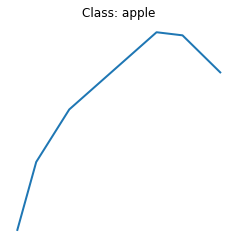


Class: eye
One-hot: tensor([0., 1., 0., 0., 0., 0., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[ 31.,  -8.,   1.],
        [ 39., -29.,   1.],
        [ 27.,  -9.,   1.],
        [ 24.,   0.,   1.],
        [ 74.,  29.,   1.]])


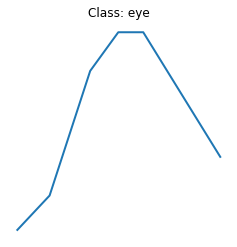


Class: square
One-hot: tensor([0., 0., 1., 0., 0., 0., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[51.,  0.,  1.],
        [49., -7.,  1.],
        [66., -4.,  1.],
        [32.,  2.,  1.],
        [ 0., 20.,  1.]])


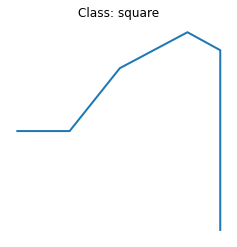


Class: triangle
One-hot: tensor([0., 0., 0., 1., 0., 0., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[-37.,  82.,   1.],
        [-13.,  37.,   1.],
        [-12.,  39.,   1.],
        [ -7.,  52.,   1.],
        [ 18.,   3.,   1.]])


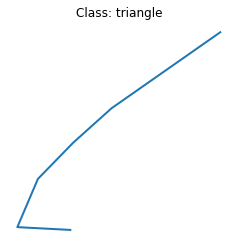


Class: circle
One-hot: tensor([0., 0., 0., 0., 1., 0., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[-24.,   0.,   1.],
        [-38.,  25.,   1.],
        [-25.,  26.,   1.],
        [-20.,  43.,   1.],
        [ -2.,  58.,   1.]])


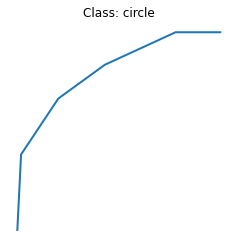


Class: pear
One-hot: tensor([0., 0., 0., 0., 0., 1., 0., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[-25.,  41.,   1.],
        [-12.,  31.,   1.],
        [ -9.,  51.,   1.],
        [  0.,  15.,   1.],
        [  8.,  17.,   1.]])


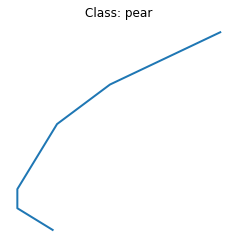


Class: hand
One-hot: tensor([0., 0., 0., 0., 0., 0., 1., 0.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[ -6., -95.,   1.],
        [-25., -35.,   1.],
        [-14., -26.,   1.],
        [ -5., -20.,   1.],
        [  5., -20.,   1.]])


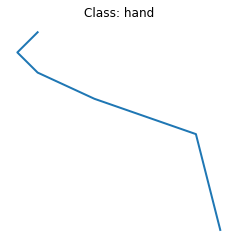


Class: car
One-hot: tensor([0., 0., 0., 0., 0., 0., 0., 1.])
Stroke shape: torch.Size([5, 3])
First 10 timesteps:
tensor([[-14.,  -2.,   1.],
        [-88.,   2.,   1.],
        [-29.,  53.,   1.],
        [-42.,   4.,   1.],
        [ -7.,   7.,   1.]])


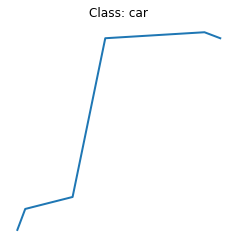

In [8]:
# ===================== CONFIG =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 8
STROKE_DIM = 3
MAX_SEQ_LEN = 5
BATCH_SIZE = 64
SAMPLES_PER_CLASS = 10   # keep small for testing

CLASSES = ["apple", "eye", "square", "triangle", "circle", "pear", "hand", "car"]
DATA_DIR = "quickdraw_data"

# ===================== DOWNLOAD =====================
def download_quickdraw_data():
    os.makedirs(DATA_DIR, exist_ok=True)

    for cls in CLASSES:
        path = os.path.join(DATA_DIR, f"{cls}.ndjson")
        url = f"https://storage.googleapis.com/quickdraw_dataset/full/simplified/{cls}.ndjson"

        if not os.path.exists(path):
            print(f"Downloading {cls}...")
            r = requests.get(url, stream=True)
            r.raise_for_status()
            with open(path, "wb") as f:
                for chunk in r.iter_content(8192):
                    f.write(chunk)
        else:
            print(f"{cls} already exists")

# ===================== LOAD DATA =====================
def load_quickdraw_data():
    data = []
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    counts = {c: 0 for c in CLASSES}

    for cls in CLASSES:
        path = os.path.join(DATA_DIR, f"{cls}.ndjson")

        with open(path, "r") as f:
            for line in f:
                if counts[cls] >= SAMPLES_PER_CLASS:
                    break

                d = json.loads(line)
                if not d.get("recognized", False):
                    continue

                strokes = []
                for stroke in d["drawing"]:
                    x, y = stroke
                    for i in range(len(x) - 1):
                        dx = x[i + 1] - x[i]
                        dy = y[i + 1] - y[i]
                        pen = 1
                        strokes.append([dx, dy, pen])

                if len(strokes) == 0:
                    continue

                data.append((class_to_idx[cls], strokes))
                counts[cls] += 1

        print(f"Loaded {counts[cls]} samples for {cls}")

    return data

# ===================== DATASET =====================
class QuickDrawDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        class_idx, strokes = self.data[idx]

        # one-hot class
        one_hot = torch.zeros(NUM_CLASSES)
        one_hot[class_idx] = 1.0

        strokes = np.array(strokes, dtype=np.float32)

        # truncate
        strokes = strokes[:MAX_SEQ_LEN]

        # pad
        if len(strokes) < MAX_SEQ_LEN:
            pad = np.zeros((MAX_SEQ_LEN - len(strokes), STROKE_DIM), dtype=np.float32)
            strokes = np.vstack([strokes, pad])

        return one_hot, torch.tensor(strokes)

# ===================== VISUALIZATION =====================
def visualize_sketch(stroke_seq, title="Sketch"):
    x, y = 0, 0
    xs, ys = [x], [y]

    for dx, dy, pen in stroke_seq:
        if pen == 0:
            continue
        x += dx
        y += dy
        xs.append(x)
        ys.append(y)

    plt.figure(figsize=(4, 4))
    plt.plot(xs, ys, linewidth=2)
    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.title(title)
    plt.show()
from torch.utils.data import random_split, DataLoader

# ===================== SPLIT DATA =====================

total_size = len(dataset)

train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Dataset Split:")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))
# ===================== RUN EVERYTHING =====================
download_quickdraw_data()
data = load_quickdraw_data()

dataset = QuickDrawDataset(data)

# ===================== PRINT ONE SAMPLE PER CLASS =====================
print("\n===== ONE SAMPLE FROM EACH CLASS =====")

# Track which classes we've already printed
printed_classes = set()

for i in range(len(dataset)):
    one_hot, stroke_seq = dataset[i]
    class_idx = torch.argmax(one_hot).item()

    if class_idx not in printed_classes:
        printed_classes.add(class_idx)

        print(f"\nClass: {CLASSES[class_idx]}")
        print("One-hot:", one_hot)
        print("Stroke shape:", stroke_seq.shape)
        print("First 10 timesteps:")
        print(stroke_seq[:10])

        visualize_sketch(
            stroke_seq.numpy(),
            title=f"Class: {CLASSES[class_idx]}"
        )

    # Stop once all classes are printed
    if len(printed_classes) == NUM_CLASSES:
        break

In [ ]:
import torch
import torch.nn as nn

# =========================
# 🔧 HYPERPARAMETERS
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_SIZE = 3          # (dx, dy, pen)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2

WINDOW_SIZE = 4
LR = 1e-4
PATIENCE = 10
EPOCHS = 50

MODEL_SAVE_PATH = "best_lstm_stroke_model.pth"

# =========================
# 🧠 MODEL DEFINITION
# =========================
class StrokePredictorLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=INPUT_SIZE,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT
        )

        self.fc = nn.Linear(HIDDEN_SIZE, INPUT_SIZE)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, H)
        last_out = out[:, -1, :]       # last timestep
        pred = self.fc(last_out)       # (B, 3)
        return pred

# Initialize model
model = StrokePredictorLSTM().to(DEVICE)

print("Model initialized successfully.")

In [ ]:
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    train_batches = 0

    for one_hot, stroke_batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):

        stroke_batch = stroke_batch.to(DEVICE)

        inputs, targets = create_windows(stroke_batch)
        if inputs is None:
            continue

        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        preds = model(inputs)
        loss = criterion(preds, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

    avg_train_loss = train_loss / max(train_batches, 1)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for one_hot, stroke_batch in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):

            stroke_batch = stroke_batch.to(DEVICE)

            inputs, targets = create_windows(stroke_batch)
            if inputs is None:
                continue

            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            preds = model(inputs)
            loss = criterion(preds, targets)

            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / max(val_batches, 1)

    scheduler.step(avg_val_loss)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {avg_train_loss:.6f}")
    print(f"Val   Loss: {avg_val_loss:.6f}")
    print("-" * 40)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("✅ Best model saved!\n")